In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import copy
import json
import random
import shutil
import collections
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch version
print(torch.__version__)
print(f"device: {device}")


2.7.1+cu126
device: cuda


In [2]:
base_path = os.path.join(os.getenv("HOME"), "workspace", "projects", "AIFFEL_quest_rs")
data_dir = os.path.join(base_path, "work", "BERT", "data")

In [3]:
corpus_file = os.path.join(data_dir, 'kowiki.txt')
prefix = 'ko_32000'
vocab_size = 32000


In [4]:
# 학습이 동작하지 않는 원인 파악
# BPE 학습 로그(merge step별 출력)가 너무 많아 Jupyter 출력 파이프가 막혀 멈춘 것처럼 보였음 -> 로그 레벨을 낮춰 방지
spm.set_min_log_level(2)  # 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

In [6]:
vocab = spm.SentencePieceProcessor()
vocab.load(os.path.join(f"{prefix}.model"))

True

In [7]:
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

In [8]:
# BERT 학습 데이터 구성을 위해 전체에서 15%를 [MASK] 토큰으로 랜덤하게 q변경
# Masked LM 태스크를 구성할 땐 띄어쓰기 단위로 한꺼번에 마스킹
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

# NSP pair 생성 함수
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

In [9]:
# 데이터 생성 함수
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

# np memmap 처리 함수
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [10]:
pretrain_json_path = os.path.join(data_dir, "bert_pre_train.json")
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/3957761 [00:00<?, ?it/s]

In [11]:
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [12]:
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([    5,  2386,  2163, 27596, 27671,   968,  8048,   173,   607,
          2387,   317, 27604,  3929, 27625,  5550,     6,     6,  8198,
          9855,  1448,  1922, 27625,  5550,    37,    18,   451,     6,
             6,  4865,  6441,     6,  5550, 27646, 18203,   927,   157,
         27821,    61, 27773,   531, 27604,  3371,   524,  3408,   673,
          5550,    18,   981, 13265, 27599,  5550,  5054,   981,  4741,
           151, 27604,  6944,  3554,  6717, 12789,  2046,  5894,  1854,
         27599,     4, 21241, 25243,  3324, 22556,   104, 27610, 27686,
         27718, 25243,  7503,   416,     6,     6,   160, 27662,     7,
         27629,   203,   241, 27602,  4869,   788,   243,  5919,   796,
           663,  1648,  3899, 27625,   203,  3009, 27625, 27616,    16,
         27599, 16414,   207,  4616,     6,     6,     6,     6,  4267,
           429,  5348, 27626, 14410,  1607, 27599,     6,     6,     6,
          8637, 27599,    13,    81, 25984,     6, 15035, 27873,

In [13]:
# 모델 구현 
import bert_model

In [20]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

# n_vocab/i_pad/n_seq는 실제 학습된 SentencePiece vocab과 데이터 생성 시 사용한 길이(128)에 맞춤
config = Config({
    "d_model": 512,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 128,
    "n_vocab": len(vocab),
    "i_pad": vocab.pad_id()
})

In [15]:
batch_size = 5

# load_pre_train_data가 반환하는 (enc_tokens, segments), (labels_nsp, labels_mlm)는
# np.memmap(numpy) 튜플이므로 torch.Tensor로 변환한 뒤 개별 인자로 풀어서 넣어야 함
enc_tokens, segments = pre_train_inputs
labels_nsp, labels_mlm = pre_train_labels

train_dataset = TensorDataset(
    torch.from_numpy(enc_tokens).long(),
    torch.from_numpy(segments).long(),
    torch.from_numpy(labels_nsp).long(),
    torch.from_numpy(labels_mlm).long(),
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [16]:
# 모델 불러오기
model = bert_model.build_model_pre_train(config).to(device)

In [17]:
# loss
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask (loss가 flatten된 (bs*n_seq,) 형태이므로 mask도 동일하게 flatten)
    mask = (y_true.view(-1) != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

In [18]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
        return lr


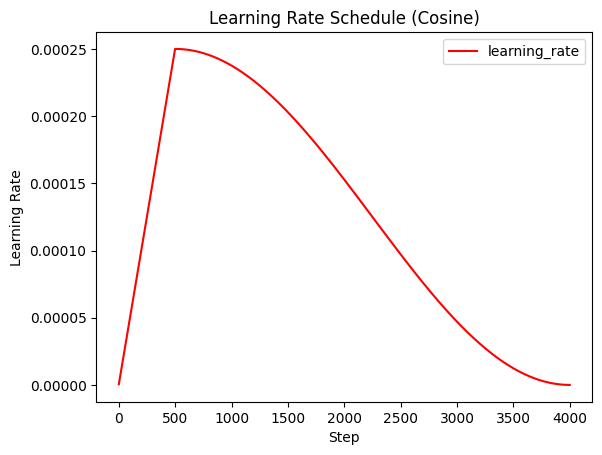

In [19]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

In [ ]:
# 학습 루프
epochs = 2
train_steps = epochs * len(train_dataloader)
warmup_steps = max(1, train_steps // 10)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=warmup_steps, max_lr=2.5e-4)

# 수렴 확인용 step별 loss 기록
nsp_loss_history = []
mlm_loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.to(device)
        labels_mlm_batch = labels_mlm_batch.to(device)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

        loss_nsp = F.cross_entropy(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)
        total_loss_batch = loss_nsp + loss_mlm

        total_loss_batch.backward()
        optimizer.step()
        scheduler.step()

        nsp_loss_history.append(loss_nsp.item())
        mlm_loss_history.append(loss_mlm.item())

        total_loss += total_loss_batch.item()
        total_acc += lm_acc(labels_mlm_batch, logits_mlm).item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader):.4f} - MLM Acc: {total_acc / len(train_dataloader):.4f}")

In [ ]:
# 학습 과정 시각화: NSP / MLM loss가 안정적으로 수렴하는지 확인
# 두 loss는 스케일이 크게 달라(NSP는 ln(2)~0.69 부근, MLM은 20배 가중) 같은 축에 겹쳐 그리지 않고 서브플롯으로 분리
def moving_average(values, window=50):
    """step별 loss는 노이즈가 커서 수렴 추세를 보려면 이동평균이 필요함"""
    values = np.asarray(values, dtype=np.float64)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
steps = np.arange(1, len(nsp_loss_history) + 1)
window = min(50, max(1, len(nsp_loss_history) // 10))

# NSP loss
axes[0].plot(steps, nsp_loss_history, color='#2a78d6', alpha=0.25, linewidth=1)
nsp_ma = moving_average(nsp_loss_history, window=window)
axes[0].plot(steps[-len(nsp_ma):], nsp_ma, color='#2a78d6', linewidth=2, label=f'moving avg (window={window})')
axes[0].set_title('NSP Loss (Next Sentence Prediction)')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MLM loss
axes[1].plot(steps, mlm_loss_history, color='#008300', alpha=0.25, linewidth=1)
mlm_ma = moving_average(mlm_loss_history, window=window)
axes[1].plot(steps[-len(mlm_ma):], mlm_ma, color='#008300', linewidth=2, label=f'moving avg (window={window})')
axes[1].set_title('MLM Loss (Masked Language Model)')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 모델 저장
model_dir = os.path.join(base_path, "work", "BERT", "model")
os.makedirs(model_dir, exist_ok=True)

checkpoint_path = os.path.join(model_dir, f"bert_pretrain_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": vars(config),
    "epoch": epochs,
    "vocab_prefix": prefix,
    "nsp_loss_history": nsp_loss_history,
    "mlm_loss_history": mlm_loss_history,
}, checkpoint_path)

print(f"모델 저장 완료: {checkpoint_path}")